In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread('/content/Psycho wallpaper for PC.jpeg', cv2.IMREAD_GRAYSCALE)
edges = cv2.Canny(image, 50, 150)

In [7]:
# --- Hough Transform from Scratch ---
def hough_transform_from_scratch(edges, rho_res=1, theta_res=np.pi/180):
    height, width = edges.shape
    diag_len = int(np.sqrt(height**2 + width**2))
    max_rho = diag_len
    rho_values = np.arange(-max_rho, max_rho, rho_res)
    theta_values = np.arange(0, np.pi, theta_res)

    # Change np.int to int to avoid deprecation error
    accumulator = np.zeros((len(rho_values), len(theta_values)), dtype=int)

    for y in range(height):
        for x in range(width):
            if edges[y, x] == 255:  # Edge pixel found
                for theta_idx, theta in enumerate(theta_values):
                    rho = int(x * np.cos(theta) + y * np.sin(theta))
                    rho_idx = np.argmin(np.abs(rho_values - rho))
                    accumulator[rho_idx, theta_idx] += 1
    return accumulator, rho_values, theta_values

In [8]:
# --- Hough Transform using OpenCV ---
def hough_transform_using_opencv(edges, rho_res=1, theta_res=np.pi/180, threshold=100):
    return cv2.HoughLines(edges, rho_res, theta_res, threshold)

In [9]:
# Perform Hough Transform from Scratch
accumulator, rho_values, theta_values = hough_transform_from_scratch(edges)

In [10]:
# Perform Hough Transform using OpenCV
lines = hough_transform_using_opencv(edges)

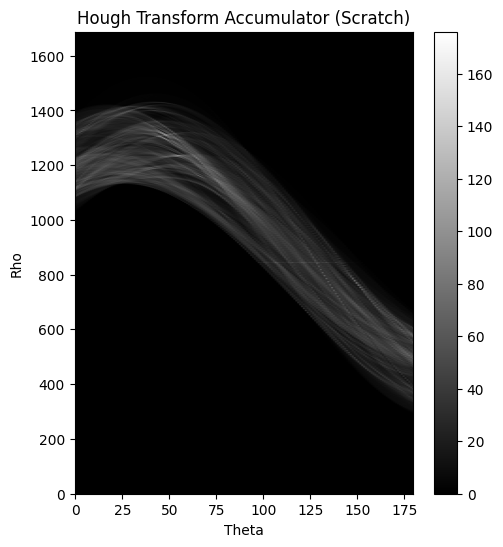

In [11]:
# --- Plotting Results ---
# Plot the Accumulator from Scratch
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(accumulator, cmap='gray', aspect='auto', origin='lower')
plt.title('Hough Transform Accumulator (Scratch)')
plt.xlabel('Theta')
plt.ylabel('Rho')
plt.colorbar()

In [12]:
# Visualize the lines detected by OpenCV on the original image
image_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
for line in lines:
    rho, theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    cv2.line(image_color, (x1, y1), (x2, y2), (0, 0, 255), 2)

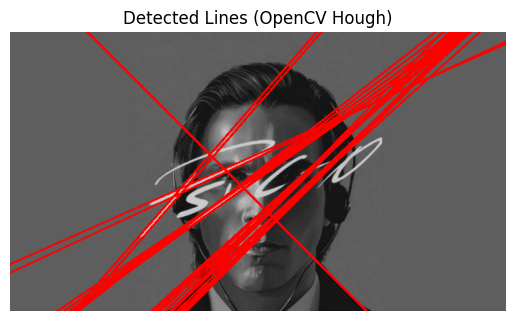

In [17]:
# Plot the original image with detected lines using OpenCV
plt.subplot(1, 1, 1)
plt.imshow(cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB))
plt.title('Detected Lines (OpenCV Hough)')
plt.axis('off')

plt.show()